# Exploratory Data Analysis (EDA)

This notebook explores the processed employee salary dataset through summary statistics and visualizations. The goal is to better understand the relationships between features before training machine learning models.

In [1]:
# Import libraries used for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt

# Display charts directly inside the notebook
%matplotlib inline

In [2]:
# Load the cleaned dataset created during the data cleaning step
df = pd.read_csv("../data/processed/processed_salary_data.csv")

# Display the first five rows
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


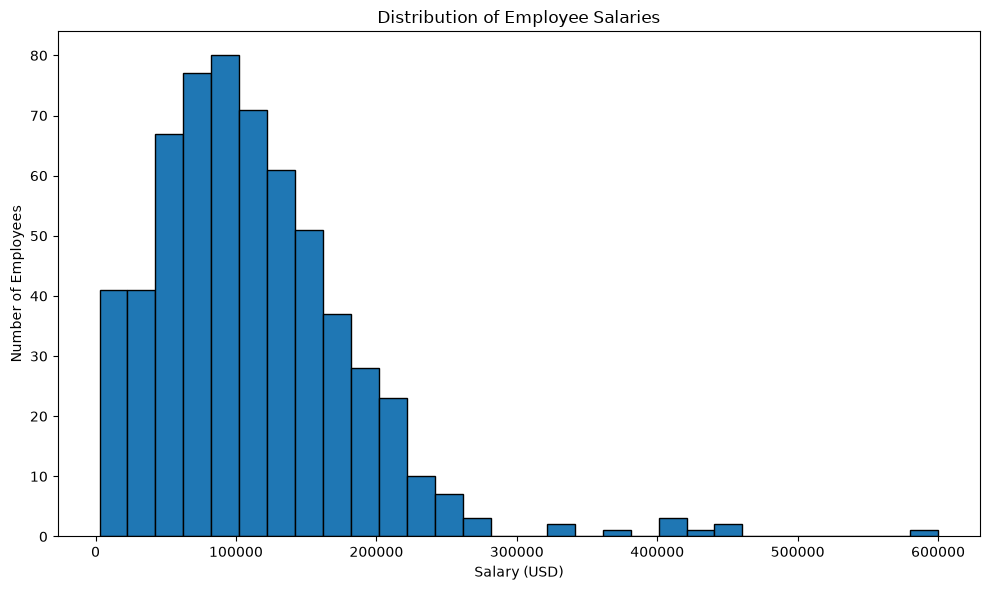

In [3]:
# Create a histogram showing the distribution of employee salaries

plt.figure(figsize=(10, 6))

plt.hist(
    df["salary_in_usd"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Employee Salaries")
plt.xlabel("Salary (USD)")
plt.ylabel("Number of Employees")

plt.tight_layout()

plt.show()

### Observation

The histogram shows that most employee salaries are concentrated between approximately $50,000 and $175,000. The salary distribution is right-skewed, indicating that while most employees earn moderate salaries, a small number earn significantly higher salaries. These high-salary observations may influence the machine learning model and should be considered during model evaluation.

## Average Salary by Experience Level

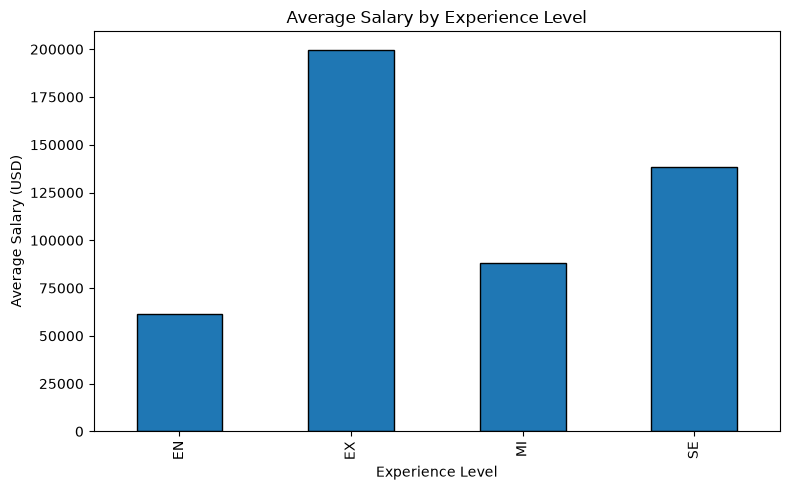

In [4]:
# Calculate the average salary for each experience level
experience_salary = (
    df.groupby("experience_level")["salary_in_usd"]
      .mean()
      .sort_index()
)

# Create a bar chart
plt.figure(figsize=(8, 5))

experience_salary.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")

plt.tight_layout()

plt.show()

### Experience Level Key

The employee experience levels shown on the chart use the following abbreviations from the dataset:

| Abbreviation | Experience Level |
|--------------|------------------|
| **EN**       | Entry-Level      |
| **MI**       | Mid-Level        |
| **SE**       | Senior-Level     |
| **EX**       | Executive-Level  |

### Observation

The average salary generally increases as employee experience level increases. Entry-level employees earn the lowest average salaries, while executive-level employees earn the highest. This suggests that experience level is likely to be one of the strongest predictors of salary in the machine learning model.

## Average Salary by Employment Type

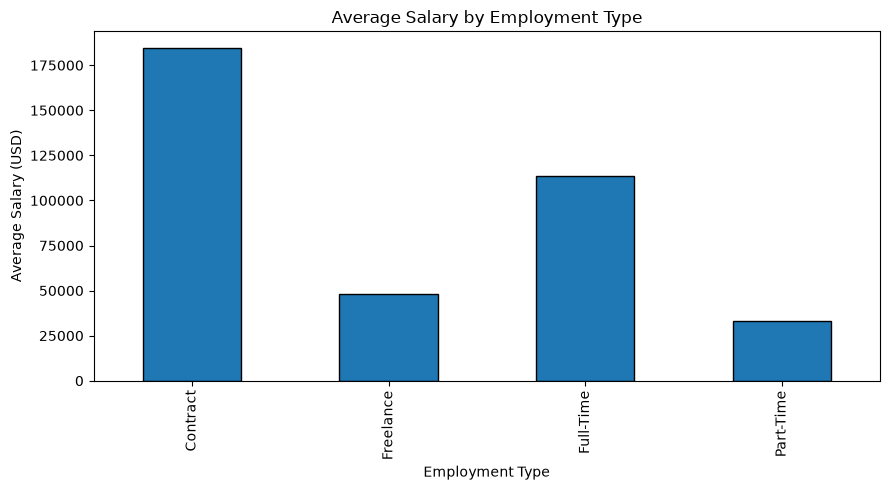

In [5]:
# Calculate the average salary for each employment type
employment_salary = (
    df.groupby("employment_type")["salary_in_usd"]
      .mean()
)

# Replace abbreviations with descriptive labels
employment_salary.index = [
    "Contract",
    "Freelance",
    "Full-Time",
    "Part-Time"
]

# Create the bar chart
plt.figure(figsize=(9,5))

employment_salary.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Salary by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Average Salary (USD)")

plt.tight_layout()

plt.show()

### Observation

The chart compares average salaries across different employment types. Full-time employees appear to earn the highest average salaries, while contract, freelance, and part-time positions generally have lower average salaries. This suggests that employment type may influence salary and could be a useful predictor in the machine learning model.

## Average Salary by Company Type

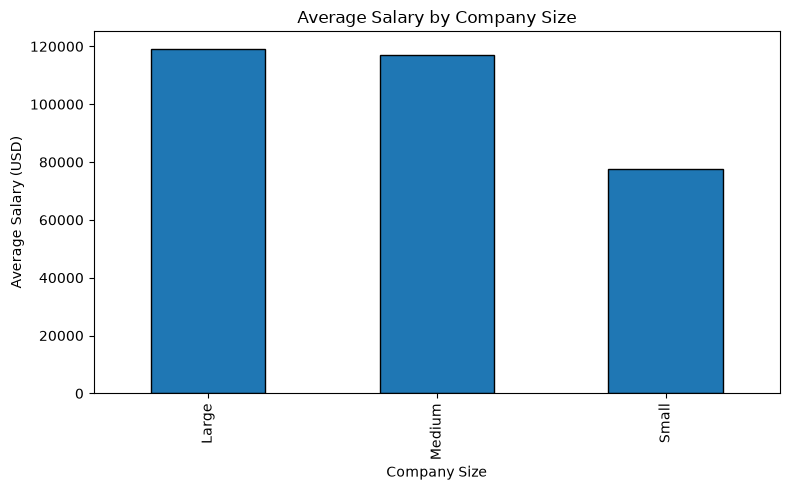

In [6]:
# Calculate the average salary by company size
company_salary = (
    df.groupby("company_size")["salary_in_usd"]
      .mean()
)

# Replace abbreviations with descriptive labels
company_salary.index = [
    "Large",
    "Medium",
    "Small"
]

plt.figure(figsize=(8,5))

company_salary.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Salary (USD)")

plt.tight_layout()

plt.show()

### Observation

Average salaries vary across company sizes. Larger organizations generally offer higher average salaries than smaller organizations, suggesting that company size may contribute to salary differences.

## Average Salary by Remote Work Ratio

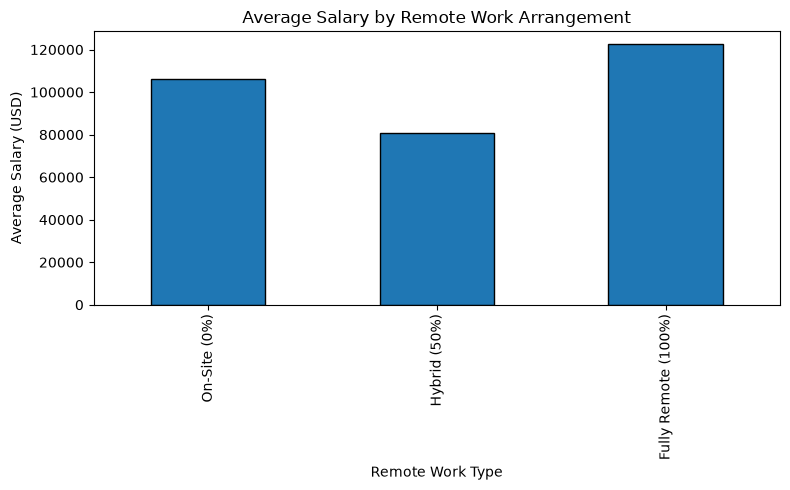

In [7]:
# Calculate average salary by remote work ratio
remote_salary = (
    df.groupby("remote_ratio")["salary_in_usd"]
      .mean()
)

# Rename the remote work categories
remote_salary.index = [
    "On-Site (0%)",
    "Hybrid (50%)",
    "Fully Remote (100%)"
]

plt.figure(figsize=(8,5))

remote_salary.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Salary by Remote Work Arrangement")
plt.xlabel("Remote Work Type")
plt.ylabel("Average Salary (USD)")

plt.tight_layout()

plt.show()

## Top 10 Highest Paying Job Titles

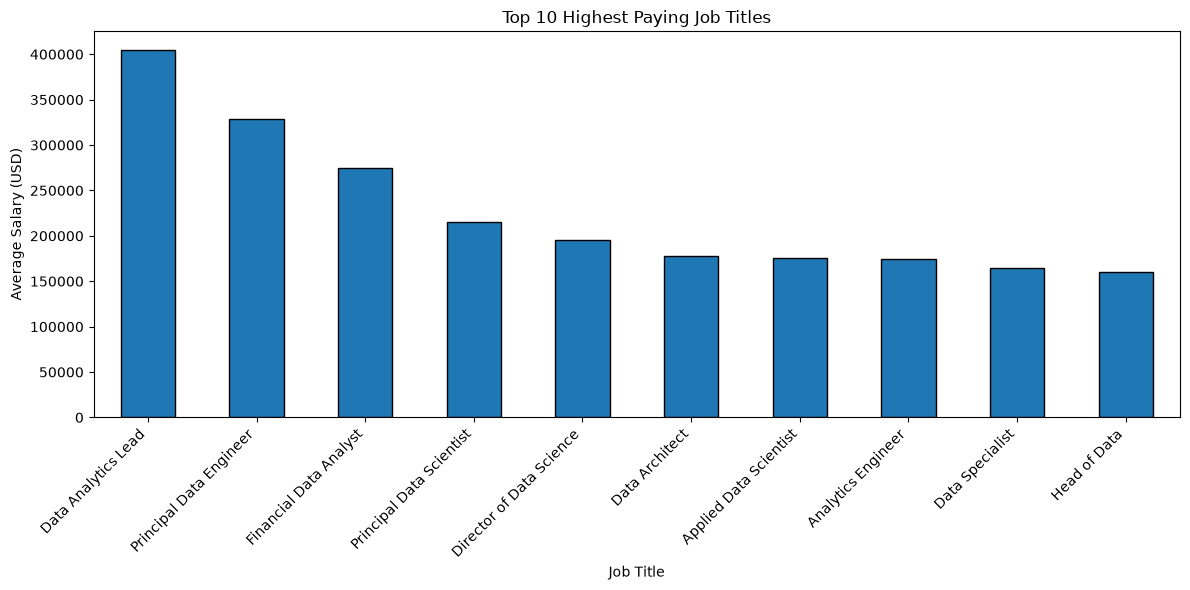

In [8]:
# Calculate the average salary by job title
job_salary = (
    df.groupby("job_title")["salary_in_usd"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

job_salary.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Top 10 Highest Paying Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

## Correlation Heatmap and Analysis of Numerical Features

The following heatmap examines the linear relationships among the numerical variables in the processed salary dataset. Correlation values range from -1 to 1. Values closer to 1 indicate a positive relationship, values closer to -1 indicate a negative relationship, and values near 0 indicate little or no linear relationship.

In [9]:
# Select the numerical variables relevant to the analysis
numeric_features = df[
    [
        "work_year",
        "remote_ratio",
        "salary_in_usd"
    ]
]

# Calculate the Pearson correlation matrix
correlation_matrix = numeric_features.corr()

# Display the correlation values
correlation_matrix

,work_year,remote_ratio,salary_in_usd
work_year,1.000000,0.076314,0.170493
remote_ratio,0.076314,1.000000,0.132122
salary_in_usd,0.170493,0.132122,1.000000


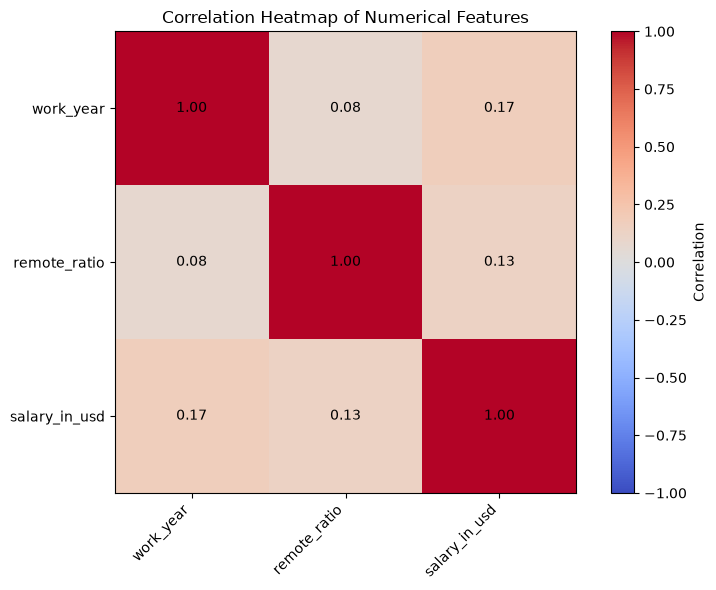

In [10]:
# Create a heatmap of the correlations among numerical variables
plt.figure(figsize=(8, 6))

# Display the correlation matrix as an image
heatmap = plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Add the variable names to both axes
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Display each correlation value inside its corresponding square
for row in range(len(correlation_matrix.columns)):
    for column in range(len(correlation_matrix.columns)):
        plt.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

# Add the title and color scale
plt.title("Correlation Heatmap of Numerical Features")
plt.colorbar(heatmap, label="Correlation")

plt.tight_layout()
plt.show()

### Correlation Findings

The heatmap shows that both numerical predictor variables have weak positive relationships with `salary_in_usd`. Work year has a correlation of **0.17** with salary, indicating that salaries tended to increase slightly across the years represented in the dataset. Remote-work ratio has a correlation of **0.13** with salary, suggesting only a small positive relationship between the amount of remote work and employee salary.

The correlation between work year and remote-work ratio is **0.08**, which indicates almost no linear relationship between those two variables. Overall, none of the numerical predictors has a strong linear correlation with salary. This suggests that categorical features such as experience level, job title, employment type, company size, and company location may be more useful for predicting salary after they are converted into numerical form during feature engineering.

These correlations describe associations only and do not show that one variable directly causes another to change.

In [11]:
print("Average salary by employment type:")
print(
    df.groupby("employment_type")["salary_in_usd"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
      .round(2)
)

print("\nAverage salary by company size:")
print(
    df.groupby("company_size")["salary_in_usd"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
      .round(2)
)

print("\nAverage salary by remote-work ratio:")
print(
    df.groupby("remote_ratio")["salary_in_usd"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
      .round(2)
)

print("\nTop 10 job titles by average salary:")
print(
    df.groupby("job_title")["salary_in_usd"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
      .head(10)
      .round(2)
)

Average salary by employment type:
                 count       mean
employment_type                  
CT                   5  184575.00
FT                 588  113468.07
FL                   4   48000.00
PT                  10   33070.50

Average salary by company size:
              count       mean
company_size                  
L               198  119242.99
M               326  116905.47
S                83   77632.67

Average salary by remote-work ratio:
              count       mean
remote_ratio                  
100             381  122457.45
0               127  106354.62
50               99   80823.03

Top 10 job titles by average salary:
                          count       mean
job_title                                 
Data Analytics Lead           1  405000.00
Principal Data Engineer       3  328333.33
Financial Data Analyst        2  275000.00
Principal Data Scientist      7  215242.43
Director of Data Science      7  195074.00
Data Architect               11  177873.9

# Summary of Exploratory Data Analysis Findings

The exploratory data analysis provided valuable insights into the employee salary dataset and identified several patterns that will help guide the development of the machine learning model.

The salary distribution is right-skewed, with most employee salaries concentrated between approximately $50,000 and $175,000. A relatively small number of employees earn substantially higher salaries, creating several high-value outliers that extend the distribution to nearly $600,000.

Employee experience level shows one of the strongest relationships with salary. Executive-level employees have the highest average salaries, followed by senior-level employees, while entry-level employees earn the lowest average salaries. This indicates that experience level is likely to be an important predictor in the salary prediction model.

Employment type also appears to influence salary. Contract employees have the highest average salary among the employment categories, followed by full-time employees. However, the contract and freelance categories contain relatively few observations compared to the full-time category, so these results should be interpreted with caution.

Company size demonstrates moderate differences in average salary. Large and medium-sized companies report similar average salaries, while small companies have noticeably lower average salaries. This suggests that company size may contribute to salary differences but is unlikely to be the sole determining factor.

Remote-work arrangements show only moderate variation in salary. Fully remote employees have the highest average salary, followed by on-site employees, while hybrid employees have the lowest average salary among the three groups. Although remote work appears to have some influence, the differences are not large enough to suggest that remote work alone is a strong predictor of salary.

The analysis of job titles revealed substantial variation in average salaries across different roles. Positions such as Data Analytics Lead, Principal Data Engineer, Principal Data Scientist, and Director of Data Science reported the highest average salaries. Because several of these job titles are represented by only a small number of observations, these averages should be interpreted carefully.

The numerical correlation analysis found weak positive relationships between the available numerical variables and salary. Work year has a correlation of 0.17 with salary, while remote-work ratio has a correlation of 0.13 with salary. These results indicate that the numerical variables alone do not strongly explain salary differences. Instead, the categorical variables—including experience level, job title, employment type, company size, and location—are expected to play a more significant role once they are encoded during feature engineering.

Overall, the exploratory analysis suggests that employee salary is influenced by a combination of professional experience, job role, employment characteristics, company characteristics, and work arrangement rather than any single factor. The next phase of the project will focus on feature engineering, encoding categorical variables, and training machine learning models to accurately predict employee salaries.

## Key Takeaways

- The dataset contains 607 complete employee records with no missing or duplicate values.
- Salary distribution is right-skewed with several high-salary outliers.
- Experience level is one of the strongest indicators of salary.
- Job title and employment characteristics show meaningful differences in average salary.
- Numerical variables alone have weak correlations with salary.
- Most predictive information is contained within categorical variables, which will require encoding before machine learning model training.